<a href="https://colab.research.google.com/github/Subhranshu-123/BIKE2/blob/main/Copy_of_T_s_global_exercise_8(dr_vinod_reddy).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("t_global.csv")
df.head()

,|,|__0,|__1,|__2,|__3,|__4,|__5,|__6,|__7,|__8,...,|__3263,|__3264,|__3265,|__3266,|__3267,|__3268,|__3269,|__3270,|__3271,|__3272
0,Date,1750-01-01T00:00:00.000,1750-02-01T00:00:00.000,1750-03-01T00:00:00.000,1750-04-01T00:00:00.000,1750-05-01T00:00:00.000,1750-06-01T00:00:00.000,1750-07-01T00:00:00.000,1750-08-01T00:00:00.000,1750-09-01T00:00:00.000,...,2021-12-01T00:00:00.000,2022-01-01T00:00:00.000,2022-02-01T00:00:00.000,2022-03-01T00:00:00.000,2022-04-01T00:00:00.000,2022-05-01T00:00:00.000,2022-06-01T00:00:00.000,2022-07-01T00:00:00.000,2022-08-01T00:00:00.000,2022-09-01T00:00:00.000
1,Monthly Anomaly_global,-0.993,-1.679,-0.192,-0.531,-1.881,-1.315,-0.319,0.13,-1.198,...,1.351,1.398,1.16,1.52,1.362,1.023,1.315,1.289,1.231,1.09
2,Monthly Unc_global,3.153,4.445,NaN,2.749,1.728,1.927,3.134,2.348,NaN,...,0.099,0.061,0.055,0.059,0.094,0.088,0.025,0.079,0.093,0.112


like reading the first page of a business report. This helps us understand what kind of data we are dealing with.

In [3]:
df.shape

(3, 3274)

In [ ]:
df.columns

Index(['Monthly Anomaly_global', 'Monthly Unc_global'], dtype='object', name='|')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3273 entries, 1750-01-01 to 2022-09-01
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Monthly Anomaly_global  3272 non-null   object
 1   Monthly Unc_global      3268 non-null   object
dtypes: object(2)
memory usage: 76.7+ KB


In [ ]:
df.describe()

|,Monthly Anomaly_global,Monthly Unc_global
count,3272,3268
unique,2038,1564
top,-0.29,0.081
freq,10,23


Data Cleaning

In [ ]:
df = pd.read_csv("t_global.csv")
df = df.transpose()
df.columns = df.iloc[0]
df = df[1:]
df = df.reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

Visualization “Seeing the Trend”

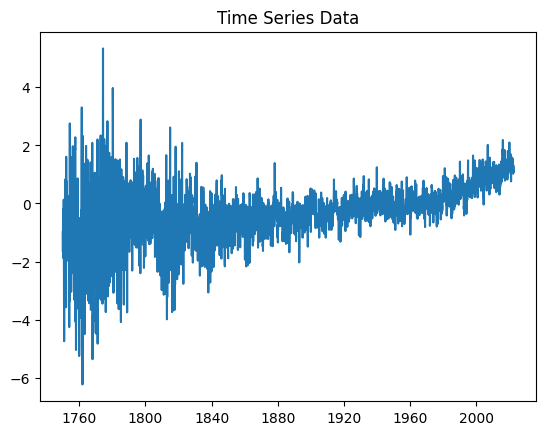

In [ ]:
import matplotlib.pyplot as plt

df['Monthly Anomaly_global'] = pd.to_numeric(df['Monthly Anomaly_global'], errors='coerce')
plt.plot(df['Monthly Anomaly_global'])
plt.title("Time Series Data")
plt.show()

Before predicting the future, we must ensure the data behaves consistently over time.
This is called stationarity.

If p-value < 0.05 → Data is stable

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Drop NaN values from the series before running adfuller
result = adfuller(df['Monthly Anomaly_global'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.12050787091198
p-value: 0.025072271950769484


Differencing — “Removing Trend to See Reality”

If the data has trend, we remove it using differencing.
This helps us focus on actual patterns instead of long-term growth.

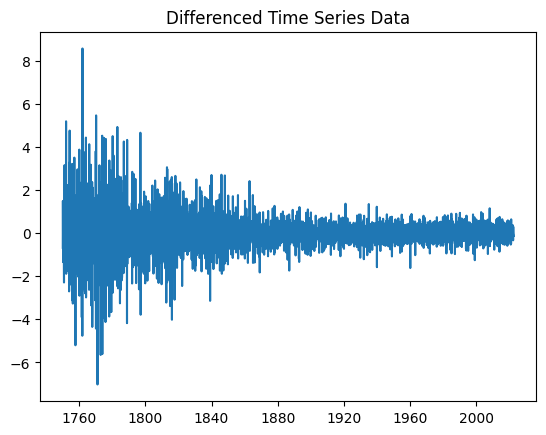

In [ ]:
df['Diff'] = df['Monthly Anomaly_global'].diff().dropna()
plt.plot(df['Diff'])
plt.title("Differenced Time Series Data")
plt.show()

ACF Plot — “How Past Influences Present”

ACF (Auto-Correlation Function) answers:
How much does the past influence the present?
Long tail → Moving Average (MA) component
Sharp cutoff → Identify lag (q)

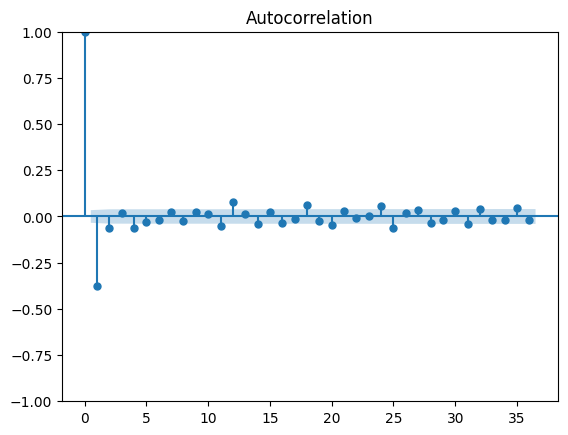

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(df['Diff'].dropna())
plt.show()

PACF Plot — “Direct Impact of Past Values”

PACF (Partial Auto-Correlation Function) answers
Which past values directly affect the present?”

Helps identify AR (Auto-Regressive) terms (p)

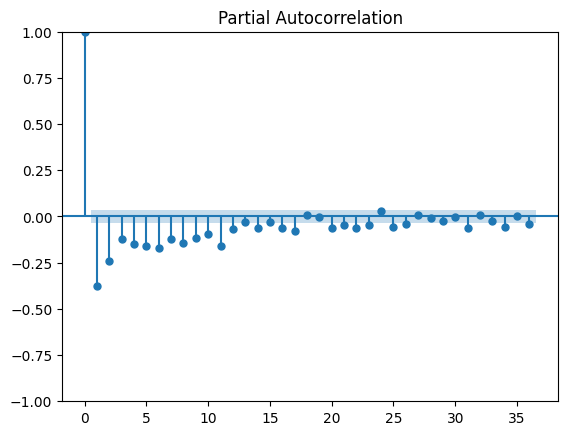

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['Diff'].dropna())
plt.show()

Moving Average — “Smoothing the Noise”

Moving average helps us remove short-term fluctuations and see the real trend — like zooming out to see the bigger picture.

In [ ]:
df['MA'] = df['Monthly Anomaly_global'].rolling(window=3).mean()
print(df[['Monthly Anomaly_global', 'MA']])

|           Monthly Anomaly_global        MA
Date                                        
1750-01-01                  -0.993       NaN
1750-02-01                  -1.679       NaN
1750-03-01                  -0.192 -0.954667
1750-04-01                  -0.531 -0.800667
1750-05-01                  -1.881 -0.868000
...                            ...       ...
2022-05-01                   1.023  1.301667
2022-06-01                   1.315  1.233333
2022-07-01                   1.289  1.209000
2022-08-01                   1.231  1.278333
2022-09-01                   1.090  1.203333

[3273 rows x 2 columns]


Seasonal Index — “Finding Patterns” Does demand repeat every year?

Seasonal index tells us:

Which months are high demand
Which months are low

In [ ]:
df['Month'] = df.index.month
seasonal_index = df.groupby('Month')['Monthly Anomaly_global'].mean()
print(seasonal_index)

Month
1    -0.312681
2    -0.261681
3    -0.408363
4    -0.168044
5    -0.275498
6    -0.247531
7    -0.137070
8    -0.207403
9    -0.417364
10   -0.319996
11   -0.389026
12   -0.450629
Name: Monthly Anomaly_global, dtype: float64


Log Transformation — “Stabilizing Growth”

if data grows rapidly (like revenue), variance increases.
Log transformation stabilizes it — making patterns easier to model

In [ ]:
import numpy as np

df['Log_Value'] = np.log(df['Monthly Anomaly_global'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Box-Cox Transformation — “Advanced Stabilization”

When log is not enough, Box-Cox is used.
It automatically finds the best transformation to make data more “normal”

In [ ]:
from scipy.stats import boxcox

# Find the minimum value in the column
min_val = df['Monthly Anomaly_global'].min()

# If the minimum value is non-positive, apply a shift
if min_val <= 0:
    # Shift the data to make all values strictly positive
    shift_amount = abs(min_val) + 0.001 # Adding a small constant to ensure strict positivity
    data_to_transform = df['Monthly Anomaly_global'] + shift_amount
else:
    data_to_transform = df['Monthly Anomaly_global']

# Remove NaN values before applying Box-Cox, as it requires finite values
data_to_transform = data_to_transform.dropna()

df.loc[data_to_transform.index, 'Boxcox_Value'], _ = boxcox(data_to_transform)
print(data_to_transform)

Date
1750-01-01    5.238
1750-02-01    4.552
1750-03-01    6.039
1750-04-01    5.700
1750-05-01    4.350
              ...  
2022-05-01    7.254
2022-06-01    7.546
2022-07-01    7.520
2022-08-01    7.462
2022-09-01    7.321
Name: Monthly Anomaly_global, Length: 3272, dtype: float64


Up Sampling
Monthly → Daily
Daily → Hourly

In [ ]:
# Convert monthly data to daily
# Ensure 'Monthly Unc_global' is numeric before resampling
df['Monthly Unc_global'] = pd.to_numeric(df['Monthly Unc_global'], errors='coerce')
df_upsampled = df.resample('D').mean()

print(df_upsampled.head())

|           Monthly Anomaly_global  Monthly Unc_global  MA  Month  Log_Value  \
Date                                                                           
1750-01-01                  -0.993               3.153 NaN    1.0        NaN   
1750-01-02                     NaN                 NaN NaN    NaN        NaN   
1750-01-03                     NaN                 NaN NaN    NaN        NaN   
1750-01-04                     NaN                 NaN NaN    NaN        NaN   
1750-01-05                     NaN                 NaN NaN    NaN        NaN   

|           Boxcox_Value  Diff  
Date                            
1750-01-01     10.652942   NaN  
1750-01-02           NaN   NaN  
1750-01-03           NaN   NaN  
1750-01-04           NaN   NaN  
1750-01-05           NaN   NaN  


Filling Missing Values — “Making Data Usable”

In [ ]:
df_upsampled_ffill = df_upsampled.fillna(method='ffill')
print(df_upsampled_ffill.head())

|           Monthly Anomaly_global  Monthly Unc_global  MA  Month  Log_Value  \
Date                                                                           
1750-01-01                  -0.993               3.153 NaN    1.0        NaN   
1750-01-02                  -0.993               3.153 NaN    1.0        NaN   
1750-01-03                  -0.993               3.153 NaN    1.0        NaN   
1750-01-04                  -0.993               3.153 NaN    1.0        NaN   
1750-01-05                  -0.993               3.153 NaN    1.0        NaN   

|           Boxcox_Value  Diff  
Date                            
1750-01-01     10.652942   NaN  
1750-01-02     10.652942   NaN  
1750-01-03     10.652942   NaN  
1750-01-04     10.652942   NaN  
1750-01-05     10.652942   NaN  


/tmp/ipykernel_7859/3367002672.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_upsampled_ffill = df_upsampled.fillna(method='ffill')


Interpolation (Smooth transition)

In [ ]:
df_upsampled_interp = df_upsampled.interpolate()

Down Sampling

Daily → Monthly
 Monthly → Yearly

this helps in seeing the big picture

In [ ]:
# Convert daily data to monthly
df_downsampled = df.resample('M').mean()

print(df_downsampled.head())

|           Monthly Anomaly_global  Monthly Unc_global        MA  Month  \
Date                                                                      
1750-01-31                  -0.993               3.153       NaN    1.0   
1750-02-28                  -1.679               4.445       NaN    2.0   
1750-03-31                  -0.192                 NaN -0.954667    3.0   
1750-04-30                  -0.531               2.749 -0.800667    4.0   
1750-05-31                  -1.881               1.728 -0.868000    5.0   

|           Log_Value  Boxcox_Value   Diff  
Date                                        
1750-01-31        NaN     10.652942    NaN  
1750-02-28        NaN      8.126141 -0.686  
1750-03-31        NaN     13.966520  1.487  
1750-04-30        NaN     12.516995 -0.339  
1750-05-31        NaN      7.437899 -1.350  


/tmp/ipykernel_7859/4204442202.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_downsampled = df.resample('M').mean()


In [ ]:
df_sum = df.resample('M').sum()
df_max = df.resample('M').max()
df_min = df.resample('M').min()
print(df_sum)
print(df_max)
print(df_min)

|           Monthly Anomaly_global  Monthly Unc_global        MA  Month  \
Date                                                                      
1750-01-31                  -0.993               3.153  0.000000      1   
1750-02-28                  -1.679               4.445  0.000000      2   
1750-03-31                  -0.192               0.000 -0.954667      3   
1750-04-30                  -0.531               2.749 -0.800667      4   
1750-05-31                  -1.881               1.728 -0.868000      5   
...                            ...                 ...       ...    ...   
2022-05-31                   1.023               0.088  1.301667      5   
2022-06-30                   1.315               0.025  1.233333      6   
2022-07-31                   1.289               0.079  1.209000      7   
2022-08-31                   1.231               0.093  1.278333      8   
2022-09-30                   1.090               0.112  1.203333      9   

|           Log_Value  B

/tmp/ipykernel_7859/1646487281.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sum = df.resample('M').sum()
/tmp/ipykernel_7859/1646487281.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_max = df.resample('M').max()
/tmp/ipykernel_7859/1646487281.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_min = df.resample('M').min()


Up Sampling vs Down Sampling

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


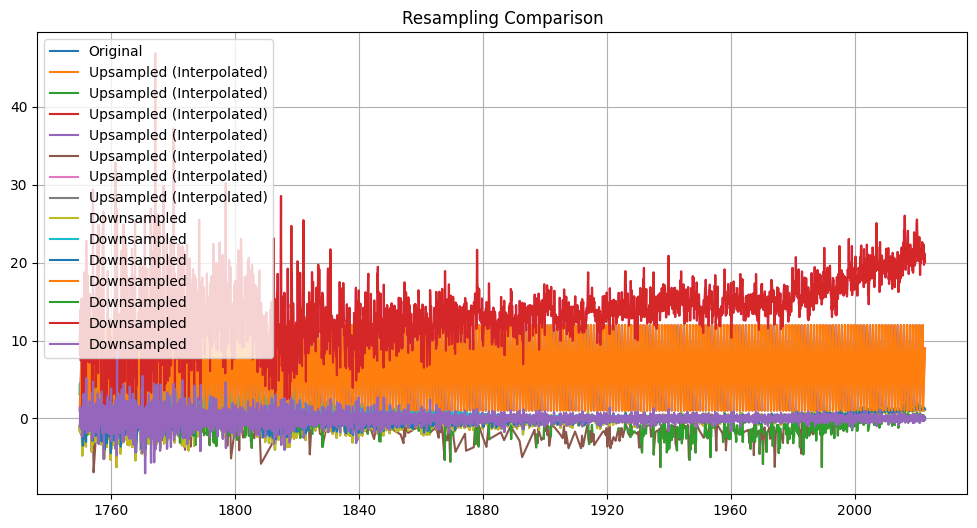

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['Monthly Anomaly_global'], label='Original')
plt.plot(df_upsampled_interp, label='Upsampled (Interpolated)')
plt.plot(df_downsampled, label='Downsampled')

plt.legend()
plt.title("Resampling Comparison")
plt.grid()
plt.show()

Trend Clarity

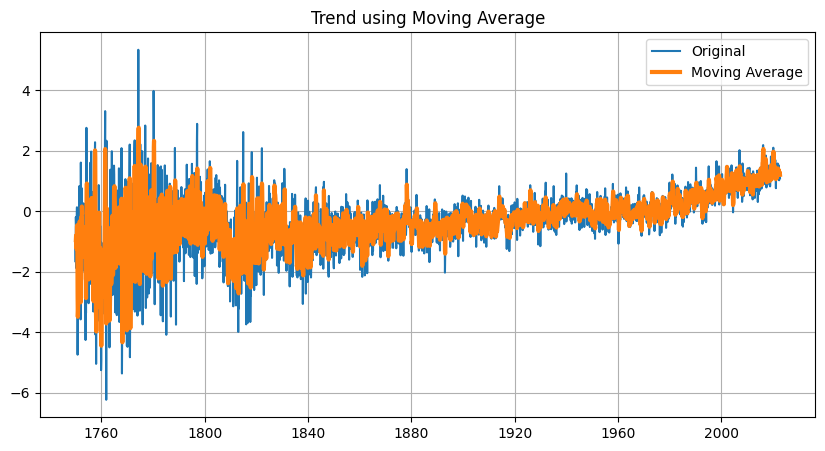

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df['Monthly Anomaly_global'], label='Original')
plt.plot(df['MA'], label='Moving Average', linewidth=3)

plt.legend()
plt.title("Trend using Moving Average")
plt.grid()
plt.show()

ARIMA Model — “Combining Everything”

Now we combine everything:

p → from PACF
d → number of differencing
q → from ACF

We train the model using past data

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Monthly Anomaly_global'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:     Monthly Anomaly_global   No. Observations:                 3273
Model:                     ARIMA(1, 1, 1)   Log Likelihood               -3707.376
Date:                    Sat, 18 Apr 2026   AIC                           7420.752
Time:                            14:32:40   BIC                           7439.032
Sample:                        01-01-1750   HQIC                          7427.298
                             - 09-01-2022                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2995      0.009     34.232      0.000       0.282       0.317
ma.L1         -0.9714      0.003   -340.498      0.000      -0.977      -0.966
sigma2         0.564

Forecasting — “Seeing the Future

In [ ]:
forecast = model_fit.forecast(steps=10)

print(forecast)

2022-10-01    1.215391
2022-11-01    1.252940
2022-12-01    1.264184
2023-01-01    1.267552
2023-02-01    1.268560
2023-03-01    1.268862
2023-04-01    1.268952
2023-05-01    1.268979
2023-06-01    1.268987
2023-07-01    1.268990
Freq: MS, Name: predicted_mean, dtype: float64


Plot Forecast vs Actual

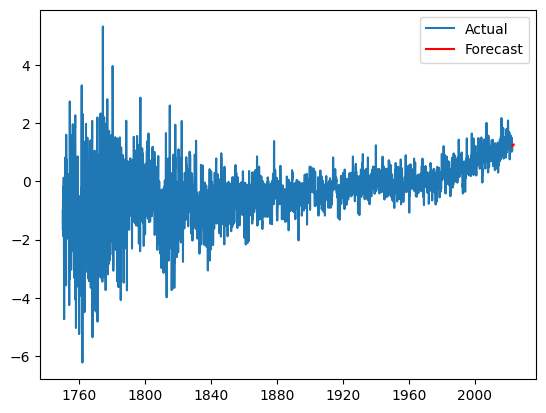

In [ ]:
plt.plot(df['Monthly Anomaly_global'], label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()

!pip install pmdarima

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.4 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima

real business scenarios, we want automation + accuracy.

Auto ARIMA tries multiple combinations and selects the best one based on:

AIC (Akaike Information Criterion)
BIC (Bayesian Information Criterion)
Lower values = Better model

In [ ]:
auto_model = auto_arima(
    df['Monthly Anomaly_global'].dropna(),
    seasonal=False,        # Set True if seasonal data
    stepwise=True,
    trace=True,            # Shows model selection process
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=7424.482, Time=3.33 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8734.467, Time=0.35 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8236.670, Time=0.21 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7687.539, Time=2.79 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8732.468, Time=0.11 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=7416.931, Time=4.07 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=7458.214, Time=2.58 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=7420.517, Time=1.96 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=7417.585, Time=6.44 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=7428.351, Time=5.85 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=7416.412, Time=3.47 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=8041.075, Time=0.46 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=7418.402, Time=3.80 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=7992.850, Time=0.66 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept

Extract Best Parameters -optimal configuration

In [ ]:
print("Best ARIMA Order:", auto_model.order)

Best ARIMA Order: (2, 1, 1)


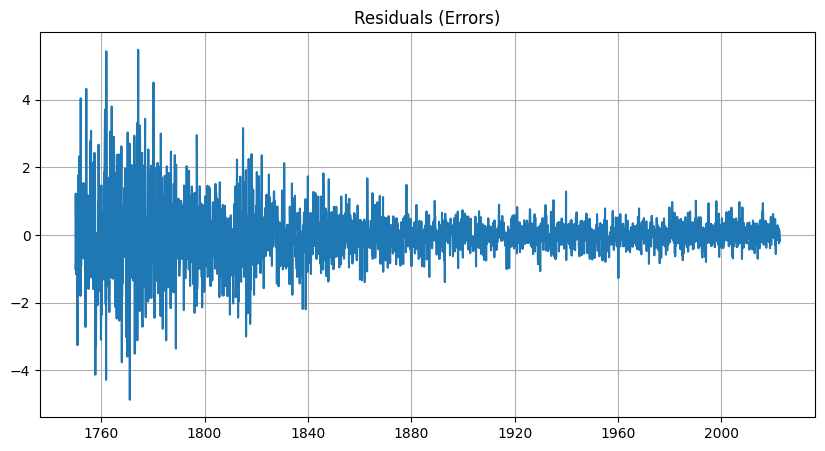

In [ ]:
residuals = auto_seasonal_model.resid()

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals (Errors)")
plt.grid()
plt.show()


Forecast Using Auto ARIMA

We now generate predictions using the best possible model automatically selected.

In [ ]:
forecast_auto = auto_model.predict(n_periods=10)

print(forecast_auto)

3272    1.229016
3273    1.263699
3274    1.280503
3275    1.287456
3276    1.290747
3277    1.292533
3278    1.293719
3279    1.294662
3280    1.295509
3281    1.296316
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Compare Manual vs Auto ARIMA

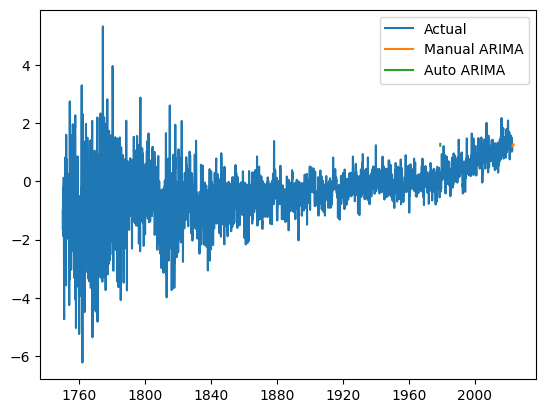

In [ ]:
plt.plot(df['Monthly Anomaly_global'], label='Actual')
plt.plot(forecast, label='Manual ARIMA')
plt.plot(forecast_auto, label='Auto ARIMA')
plt.legend()
plt.show()

In [ ]:
auto_seasonal_model = auto_arima(
    df['Monthly Anomaly_global'].dropna(),
    seasonal=True,     # Enable seasonality
    m=12,              # Example: monthly data
    stepwise=True,
    trace=True,
    suppress_warnings=True
)

print(auto_seasonal_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=7387.042, Time=18.47 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=8734.467, Time=0.42 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=8210.534, Time=1.47 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=7662.824, Time=3.48 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=8732.468, Time=0.09 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=7393.047, Time=10.27 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=7389.801, Time=15.27 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=7388.150, Time=37.95 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=7388.432, Time=33.89 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=7424.482, Time=3.43 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=7386.451, Time=45.98 sec
 ARIMA(1,1,2)(0,0,2)[12] intercept   : AIC=7378.871, Time=44.69 sec
 ARIMA(1,1,2)(0,0,1)[12] intercept   : AIC=7384.995, Time=23.70 sec
 ARIMA(1,1,2)(1,0,2)[12] intercept   : AIC=7380.711, Time=37.16 sec
 ARIMA(1,1

Extract Seasonal Orders

We now get both:

Core behavior
Seasonal pattern

m tells the model how often patterns repeat.

Monthly data	12

Quarterly data	4

Weekly data	7

Daily (hourly)	24

In [ ]:
print("Best Order:", auto_seasonal_model.order)
print("Best Seasonal Order:", auto_seasonal_model.seasonal_order)

Best Order: (1, 1, 2)
Best Seasonal Order: (1, 0, 1, 12)


Forecast with Seasonal Model

In [ ]:
forecast_seasonal = auto_seasonal_model.predict(n_periods=12)

print(forecast_seasonal)

3272    1.260270
3273    1.260752
3274    1.286126
3275    1.312563
3276    1.265986
3277    1.341443
3278    1.296852
3279    1.234274
3280    1.255760
3281    1.266077
3282    1.255031
3283    1.256813
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Compare All Models

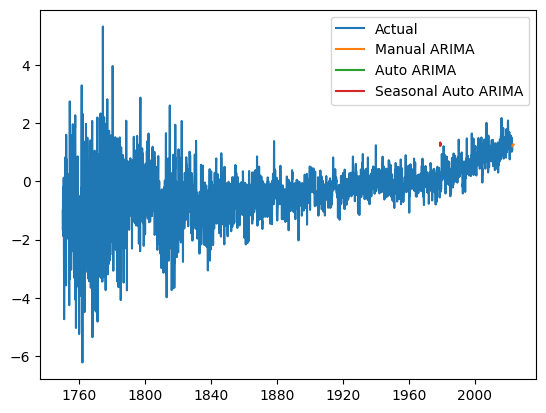

In [ ]:
plt.plot(df['Monthly Anomaly_global'], label='Actual')
plt.plot(forecast, label='Manual ARIMA')
plt.plot(forecast_auto, label='Auto ARIMA')
plt.plot(forecast_seasonal, label='Seasonal Auto ARIMA')
plt.legend()
plt.show()

Model Evaluation — “How Good Are Our Predictions?”

RMSE → penalizes large errors
MAPE → gives % error (business-friendly)

Lower RMSE = better model
Sensitive to large errors

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_model(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return rmse, mape

In [ ]:
# Example: align actual values with forecast horizon
actual_arima = df['Monthly Anomaly_global'][-len(forecast):]
rmse_arima, mape_arima = evaluate_model(actual_arima, forecast)

actual_auto = df['Monthly Anomaly_global'][-len(forecast_auto):]
rmse_auto, mape_auto = evaluate_model(actual_auto, forecast_auto)

actual_seasonal = df['Monthly Anomaly_global'][-len(forecast_seasonal):]
rmse_seasonal, mape_seasonal = evaluate_model(actual_seasonal, forecast_seasonal)

print(rmse_arima, mape_arima)
print(rmse_auto, mape_auto)
print(rmse_seasonal, mape_seasonal)

0.14805319315972895 nan
0.1504833318671851 nan
0.14094917794436387 nan


/tmp/ipykernel_7859/2632773830.py:6: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((actual - predicted) / actual)) * 100
/tmp/ipykernel_7859/2632773830.py:6: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((actual - predicted) / actual)) * 100


Accuracy Comparison Table

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Manual ARIMA", "Auto ARIMA", "Seasonal Auto ARIMA"],
    "RMSE": [rmse_arima, rmse_auto, rmse_seasonal],
    "MAPE (%)": [mape_arima, mape_auto, mape_seasonal]
})

results.sort_values(by="RMSE", inplace=True)
print(results)

                 Model      RMSE  MAPE (%)
2  Seasonal Auto ARIMA  0.140949       NaN
0         Manual ARIMA  0.148053       NaN
1           Auto ARIMA  0.150483       NaN


Forecast Comparison

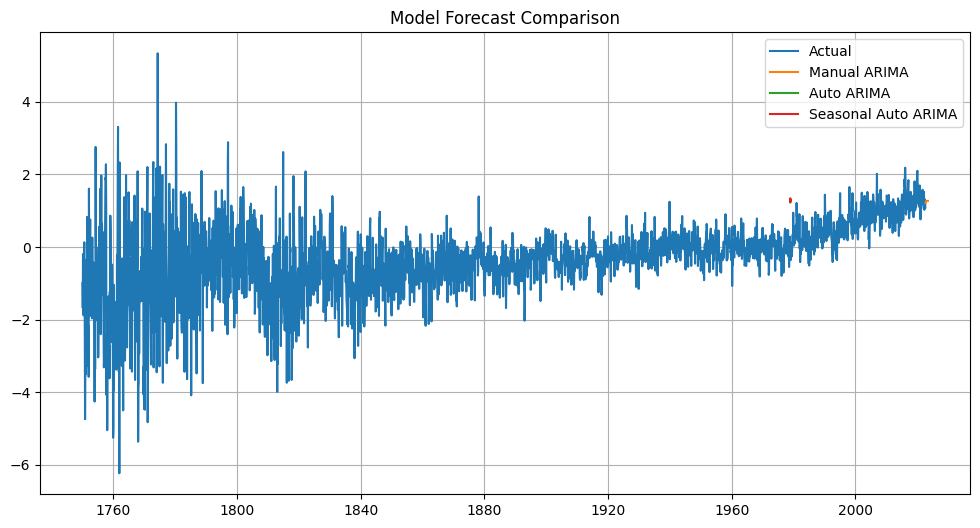

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['Monthly Anomaly_global'], label='Actual')
plt.plot(forecast, label='Manual ARIMA')
plt.plot(forecast_auto, label='Auto ARIMA')
plt.plot(forecast_seasonal, label='Seasonal Auto ARIMA')

plt.legend()
plt.title("Model Forecast Comparison")
plt.grid()
plt.show()

Error Comparison Bar Chart — “Clear Winner

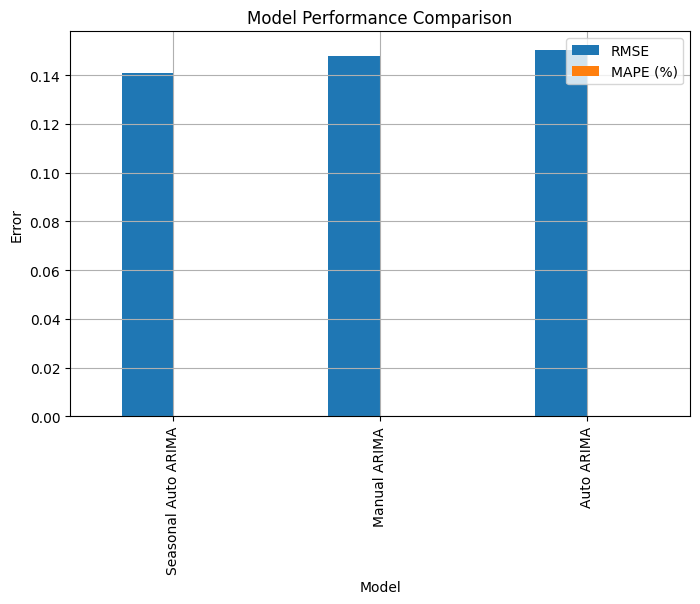

In [ ]:
results.set_index("Model")[["RMSE","MAPE (%)"]].plot(kind='bar', figsize=(8,5))

plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.grid()
plt.show()